# Классификация ботов

**Описание подхода**

1. **Очистка.** Оставляем только события внутри суточного окна cookie, привожу `platform` к трём значениям, убираю полные дубликаты строк и сортирую события по времени.
2. **Валидация.** Тест лежит строго позже обучающей выборки, поэтому валидируем строго по времени. Берем схему расширяющегося окна, 4 валидационных блока по 2 суток, обучение - все дни до своего валидационного блока.
3. **Признаки.** 5 групп поверх событий cookie: счётчики `base_`, ритм `tm_`, разнообразие контента `div_`, координаты курсора `ptr_`, клиент и возраст cookie `cl_`. Все считаются только по событиям внутри окна.
4. **Baseline.** Cлучайный лес на `base_`
5. **MVP.** CatBoost на всех признаках.
6. **В решение не взял:** Перебор 30 конфигураций гиперпараметров CatBoost не принёс улучшений(Optuna), отличие на 0.0004, их настройка подгоняет их под конкретные фолды(не меняет качество модели). А отбор признаков, не целесообразен, так как все группы признаков несут в себе положительный прирост информации и CatBoost справляется с их количеством и шумом (переобучения нет). Можно сделать вывод, что вся информация заложена в признаках и мы упираемся в информативность данных, а не в качество алгоритма или его настройки.
7. **Финальная модель.** CatBoost на всей тестовой выборке.
8. **Библиотеки:** pandas, numpy, scikit-learn, CatBoost, matplotlib. Python 3.12.9, версии в `requirements.txt`



## Зависимости

In [1]:
import re
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

# Единственный источник случайности во всём ноутбуке.
SEED = 42
SEEDS = tuple(SEED + i for i in range(5))
# Число потоков фиксирую: CatBoost воспроизводим только при неизменном их количестве.
N_JOBS = 8
CLASS_NAMES = {0: 'человек', 1: 'бот'}

In [2]:
from metric import pr_curve, precision_at_recall, recall_at_fpr

## Загрузка и очистка данных

### Data

In [3]:
data_train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
data_test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

print(f'train: {data_train.shape} \ntest: {data_test.shape} \nevents: {events.shape}')

train: (11091, 5) 
test: (4909, 4) 
events: (328905, 14)


In [4]:
data_train.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [5]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 11091 entries, 0 to 11090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          11091 non-null  str           
 1   cookie_created_at  11091 non-null  datetime64[us]
 2   window_start_ts    11091 non-null  datetime64[us]
 3   window_end_ts      11091 non-null  datetime64[us]
 4   target             11091 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(1)
memory usage: 433.4 KB


In [6]:
print(data_train['window_start_ts'].min().date())
print(data_train['window_start_ts'].max().date())

2026-04-06
2026-04-19


In [7]:
print(data_train['target'].value_counts())
print('Доля ботов в data_train:', data_train.target.mean().round(4))

target
0    10192
1      899
Name: count, dtype: int64
Доля ботов в data_train: 0.0811


8.1% ботов, классы не сбалансированы.

In [8]:
data_test.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21


In [9]:
data_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          4909 non-null   str           
 1   cookie_created_at  4909 non-null   datetime64[us]
 2   window_start_ts    4909 non-null   datetime64[us]
 3   window_end_ts      4909 non-null   datetime64[us]
dtypes: datetime64[us](3), str(1)
memory usage: 153.5 KB


In [10]:
print(data_test['window_start_ts'].min().date())
print(data_test['window_start_ts'].max().date())

2026-04-20
2026-04-26


Объединим train и test в одну таблицу meta, где index - cookie_id, у тестовой выборки будет target = NaN и дополнительно флаг is_test = True. Строки отсортируем по `(window_start_ts, cookie_id)`, чтобы порядок не зависел от порядка строк в файлах.

In [11]:
meta = pd.concat([data_train.assign(is_test=False), data_test.assign(is_test=True)], ignore_index=True)
meta = meta.sort_values(['window_start_ts', 'cookie_id']).set_index('cookie_id')

assert meta.index.is_unique, 'cookie_id должен быть уникален в train и test'
assert (meta['cookie_created_at'] < meta['window_start_ts']).all(), 'кука создана раньше начала окна'
assert (meta['window_end_ts'] - meta['window_start_ts'] == pd.Timedelta(days=1)).all(), 'окно = сутки'
train_last = meta.loc[~meta['is_test'], 'window_start_ts'].max()
test_first = meta.loc[meta['is_test'], 'window_start_ts'].min()
assert train_last < test_first, 'test должен лежать строго позже train'

train_days = meta.loc[~meta['is_test'], 'window_start_ts']
test_days = meta.loc[meta['is_test'], 'window_start_ts']
print(f'cookie: train {(~meta['is_test']).sum()}, test {meta['is_test'].sum()};'
      f'доля ботов в train {meta['target'].mean():.4f}')
print(f'train: {train_days.min().date()} - {train_days.max().date()},'
      f'test: {test_days.min().date()} - {test_days.max().date()}')
meta.head()

cookie: train 11091, test 4909;доля ботов в train 0.0811
train: 2026-04-06 - 2026-04-19,test: 2026-04-20 - 2026-04-26


,cookie_created_at,window_start_ts,window_end_ts,target,is_test
cookie_id,,,,,
ck_0010ec3874fb5378,2025-12-24 14:30:54,2026-04-06,2026-04-07,0.0,False
ck_008c04d82d0561f5,2026-01-02 23:57:46,2026-04-06,2026-04-07,0.0,False
ck_00c4ffd7008dcb87,2026-04-04 14:32:50,2026-04-06,2026-04-07,0.0,False
ck_00f708f4ee157b65,2026-01-28 02:24:44,2026-04-06,2026-04-07,0.0,False
ck_01398e0204df2412,2026-02-06 15:40:12,2026-04-06,2026-04-07,0.0,False


Вывод:
- 11091 cookie в train, 4909 в test;
- 8.1% ботов в train;
- в train 14 суточных окон, в test 7 суточных окон;
- test строго позже train, необходима валидация по времени;
- cookie_id уникальны, окно = суткам, cookie_created_at всегда раньше начала окна. 

### Events

In [12]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [13]:
print(f'Событий: {len(events)}, уникальных cookie_id: {events['cookie_id'].nunique()}')

Событий: 328905, уникальных cookie_id: 16000


In [14]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 328905 entries, 0 to 328904
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   cookie_id      328905 non-null  str           
 1   event_ts       328905 non-null  datetime64[us]
 2   eid            328905 non-null  int64         
 3   event_name     328905 non-null  str           
 4   platform       328905 non-null  str           
 5   user_agent     328905 non-null  str           
 6   item_id        214308 non-null  float64       
 7   item_category  295985 non-null  str           
 8   item_location  305112 non-null  str           
 9   seller_type    195052 non-null  str           
 10  search_query   100402 non-null  str           
 11  search_page    100402 non-null  float64       
 12  pointer_x      108540 non-null  float64       
 13  pointer_y      108540 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(8)
memory usage

In [15]:
df_info_events = pd.DataFrame({
    "dtype": events.dtypes.astype(str),
    "n unique": events.nunique(dropna=True),
    "n missing": events.isna().sum(),
    "% missing": (events.isna().mean() * 100).round(1),
})

df_info_events

,dtype,n unique,n missing,% missing
cookie_id,str,16000,0,0.0
event_ts,datetime64[us],285094,0,0.0
eid,int64,10,0,0.0
event_name,str,10,0,0.0
platform,str,11,0,0.0
user_agent,str,148,0,0.0
item_id,float64,53856,114597,34.8
item_category,str,15,32920,10.0
item_location,str,40,23793,7.2
seller_type,str,2,133853,40.7


In [16]:
print(events['eid'].value_counts(), '\n')
print(events['event_name'].value_counts(), '\n')
print(events['platform'].value_counts(), '\n')
print(events['item_category'].value_counts())

eid
200    120817
100    100402
210     36517
400     19049
220     17403
300     11316
900      7928
500      6267
301      6125
303      3081
Name: count, dtype: int64 

event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081
Name: count, dtype: int64 

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64 

item_category
avtomobili           20822
mebel                20541
bytovaya_tehnika     20161
hobbi                20020
elektronika          20002
uslugi               19869
odezhda              19846
kvartiry_arenda      19713
kvartiry_prodazha    1970

### Очистка events

Оставляем события только внутри окна: `window_start_ts <= event_ts < window_end_ts`.

In [17]:
start_events = events['cookie_id'].map(meta['window_start_ts'])
end_events = events['cookie_id'].map(meta['window_end_ts'])
assert start_events.notna().all(), 'в событиях есть куки, которых нет ни в train, ни в test'

in_window = (events['event_ts'] >= start_events) & (events['event_ts'] < end_events)
new_events = events.loc[in_window].copy()
print(f'Удалено событий вне окна: {len(events) - len(new_events)}. Осталось {len(new_events)}')

Удалено событий вне окна: 40779. Осталось 288126


При рассмотрение колонки `platform` было замечено различное написание одинаковых платформ, приведем их к нижнему регистру и склеим синонимы.

In [18]:
PLATFORMS = ('web', 'android', 'ios')
SYNONIMS = {'desktop': 'web', 'iphone': 'ios'}

def normalize_platform(platform_values):
    return platform_values.str.lower().replace(SYNONIMS)

new_events['platform'] = normalize_platform(new_events['platform'])
print(f'Написание платформ:\n{new_events['platform'].value_counts()}')


Написание платформ:
platform
web        161262
android    112256
ios         14608
Name: count, dtype: int64


Посмотрим на полные дубликаты строк и их зависимость от класса

In [19]:
event_class = events['cookie_id'].map(meta['target']).map(CLASS_NAMES).fillna('test').rename('класс')
dup_events = events.duplicated()

print(dup_events.groupby(event_class).mean().reindex(['человек', 'бот', 'test']).round(4).to_string())
print(f'Дубликатов: {dup_events.sum()}')

класс
человек    0.0148
бот        0.0142
test       0.0150
Дубликатов: 4863


4863 копии строк, доля по классам одинаковая, значит наличие дубликатов не зависит от класса. Удалим полные дупликаты.

In [20]:
new_events = new_events.drop_duplicates()
print(f'Осталось строк: {len(new_events)}')

Осталось строк: 283830


Отсортируем события по `cookie_id, event_ts, eid`

In [21]:
new_events = new_events.sort_values(['cookie_id', 'event_ts', 'eid'], kind='mergesort').reset_index(drop=True)

Сделаю проверку ассертами очищенных событий.

In [22]:
def check_events(new_events, meta):
    start = new_events['cookie_id'].map(meta['window_start_ts'])
    end = new_events['cookie_id'].map(meta['window_end_ts'])
    assert ((new_events['event_ts'] >= start) & (new_events['event_ts'] < end)).all(), 'остались события вне окна'
    assert not new_events.duplicated().any(), 'остались полные дубликаты'
    assert set(new_events['platform'].unique()) <= set(PLATFORMS), 'неизвестная платформа'

check_events(new_events, meta)
print('Проверка очищенных событий выполнена')
new_events.head()

Проверка очищенных событий выполнена


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_00013fdfa0bd37dd,2026-04-24 18:41:16,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1012349.0,rabota,moskva,private,NaN,NaN,NaN,NaN
1,ck_00013fdfa0bd37dd,2026-04-24 19:16:53,200,item_view,android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1054355.0,rabota,moskva,private,NaN,NaN,NaN,NaN
2,ck_00013fdfa0bd37dd,2026-04-24 19:16:54,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1015683.0,detskie_tovary,habarovsk,pro,NaN,NaN,NaN,NaN
3,ck_00013fdfa0bd37dd,2026-04-24 19:17:05,200,item_view,android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1028622.0,avtomobili,moskva,private,NaN,NaN,NaN,NaN
4,ck_00013fdfa0bd37dd,2026-04-24 20:05:05,500,login,android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Валидация

Так как время в тестовой выборке строго после обучающей, в валидации будем повторять такую же ситуацию: учимся на прошлом, проверяем на будующем. Поэтому возьмем схему расширяющегося окна, 4 валидационных блока по 2 суток, обучение - все дни до своего валидационного блока.

In [23]:
FOLD_DATES = [('2026-04-12', '2026-04-14'), ('2026-04-14', '2026-04-16'),
              ('2026-04-16', '2026-04-18'), ('2026-04-18', '2026-04-20')]

meta_train = meta.loc[~meta['is_test']]
train_ids = meta_train.index
y = meta_train['target'].to_numpy().astype(int)
window_start = meta_train['window_start_ts'].to_numpy()

def make_fold(name, train_mask, valid_mask):
    return {'name': name, 'train_index': np.flatnonzero(train_mask), 'valid_idx': np.flatnonzero(valid_mask)}

folds = []
for a, b in FOLD_DATES:
    a, b = np.datetime64(a), np.datetime64(b)
    name = f'{str(a)} - {str(b)}'
    folds.append(make_fold(name, window_start < a, (window_start >= a) & (window_start < b)))

print(pd.DataFrame([{'фолд': f['name'], 'обучение': len(f['train_index']), 'валидация': len(f['valid_idx']),
                     'ботов в валидации': int(y[f['valid_idx']].sum())}
                    for f in folds]).to_string(index=False))

                   фолд  обучение  валидация  ботов в валидации
2026-04-12 - 2026-04-14      5113       1660                120
2026-04-14 - 2026-04-16      6773       1627                135
2026-04-16 - 2026-04-18      8400       1453                126
2026-04-18 - 2026-04-20      9853       1238                 94


Мы видим, что в фолдк 94-135 ботов. Сдвиг нескольких cookie через порог будет заметно двигать precision, поэтому для оценки разницы моделей будем использовать бутстреп.

In [24]:
by_day = meta_train.groupby(meta_train['window_start_ts'].dt.date)['target'].agg(['size', 'mean'])
print((by_day.rename(columns={'size': 'cookie', 'mean': 'доля ботов'}).round(3)).to_string())

                 cookie  доля ботов
window_start_ts                    
2026-04-06          772       0.088
2026-04-07          797       0.074
2026-04-08          834       0.084
2026-04-09          902       0.073
2026-04-10          912       0.090
2026-04-11          896       0.088
2026-04-12          817       0.082
2026-04-13          843       0.063
2026-04-14          826       0.085
2026-04-15          801       0.081
2026-04-16          740       0.081
2026-04-17          713       0.093
2026-04-18          606       0.086
2026-04-19          632       0.066


Распределение ботов по дням сопостовимо между собой.

## Признаки

Все признаки будем строить только по очищенным событиям внутри окна.

Удалим колонку `target` и метку `is_test`, чтобы не было утечек

In [25]:
meta_nt = meta.drop(columns=['target', 'is_test'])

Будующие признаки поделим на 5 групп с соответствующими вопросами и гипотезами.

| группа | вопрос | гипотеза |
|---|---|---|
| `base_` | сколько и чего кука сделала | у бота больше просмотров и меньше контактных действий |
| `tm_` | в каком ритме | бот совершает действия с одинаковыми промежутками времени, человек - нет|
| `div_` | что именно смотрит | бот проходит по каталогу: одна категория, много объявлений, страницы выдачи подряд |
| `ptr_` | как двигается курсор | у скрипта координат нет или они цикличные |
| `cl_` | чем зашёл и сколько живёт кука | нестандартный клиент, свежая кука |

Пропуски по счетчикам буду заполнять нулями, а статистики оставляю NaN

### `base_` - счетчики

In [26]:
new_events['event_name'].value_counts()

event_name
item_view               106447
search_results_view      88478
photo_swipe              32570
favorite_add             17012
seller_page_view         15343
contact_phone_show       10145
login                     5578
contact_chat_open         5479
contact_message_sent      2778
Name: count, dtype: int64

Посчитаем по событиям: сколько всего событий, сколько разных объявлений, сколько событий каждого типа.

In [27]:
BASE_EVENTS = ['search_results_view', 'item_view', 'photo_swipe', 'seller_page_view',
               'contact_phone_show', 'contact_chat_open', 'contact_message_sent',
               'favorite_add', 'login']


def build_base(new_events, meta):
    counts = pd.crosstab(new_events['cookie_id'], new_events['event_name'])
    counts = counts.reindex(columns=BASE_EVENTS, fill_value=0).add_prefix('base_n_')
    # fill_value=0: cookie ничего не делала
    g = new_events.groupby('cookie_id')
    feats = pd.concat([g.size().rename('base_n_events'),
                       g['item_id'].nunique().rename('base_item_nunique'), counts], axis=1)
    return feats.reindex(meta.index, fill_value=0).astype('float64')

### `tm_` - ритм

Посчитаем паузы между соседними событиями cookie (медиану, разброс, долю пауз), плотность сессий(разрыв больше 30 минут, будем считать как новый визит), пиковую частоту событий и время суток. Также паузы после конкретных типов событий, например, человеку нужно больше времени после открытия объявления чтобы его прочитать.

In [28]:
CONTACTS = ['contact_phone_show', 'contact_chat_open', 'contact_message_sent']
GAP_AFTER = [('item_view', 'item_view'), ('search_results_view', 'search_results'),
             ('seller_page_view', 'seller_page'), ('photo_swipe', 'photo_swipe')]


def build_timing(new_events, meta):
    cid = new_events['cookie_id']
    # new_events отсортирован, поэтому разница внутри cookie - пауза до
    # предыдущего события. У первого события NaN
    gap = new_events.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()
    ok = gap.notna()
    by_gap = gap.where(ok).groupby(cid)
    gap_mean, gap_std = by_gap.mean(), by_gap.std()
    median_per_row = gap.groupby(cid).transform('median')

    def share(condition):
        # Cтроки без паузы становятся NaN и в среднее не попадают
        return condition.astype(float).where(ok).groupby(cid).mean()

    cols = {
        'tm_gap_median': by_gap.median(), 'tm_gap_mean': gap_mean, 'tm_gap_std': gap_std,
        'tm_gap_cv': gap_std / (gap_mean + 1.0), # +1 для избежания деления на 0
        'tm_gap_p10': by_gap.quantile(0.10), 'tm_gap_p90': by_gap.quantile(0.90),
        'tm_gap_frac_zero': share(gap == 0), 'tm_gap_frac_le1': share(gap <= 1),
        'tm_gap_frac_near_median': share((gap - median_per_row).abs() <= 1),
    }
    gap_ok, cid_ok = gap.loc[ok], cid.loc[ok]
    cols['tm_gap_unique_ratio'] = gap_ok.groupby(cid_ok).nunique() / gap_ok.groupby(cid_ok).size()

    g = new_events.groupby('cookie_id')
    first_ts, last_ts = g['event_ts'].min(), g['event_ts'].max()
    cols['tm_events_per_min'] = g.size() / ((last_ts - first_ts).dt.total_seconds() / 60.0 + 1.0)

    session = (gap.isna() | (gap > 30 * 60)).groupby(cid).cumsum() # разрыв больше 30 мин = новый визит
    session_size = new_events.groupby([cid, session]).size()
    cols['tm_events_per_session_mean'] = session_size.groupby(level=0).mean()
    cols['tm_events_per_session_max'] = session_size.groupby(level=0).max()
    cols['tm_peak_per_min'] = new_events.groupby([cid, new_events['event_ts'].dt.floor('min')]).size().groupby(level=0).max()
    cols['tm_peak_per_10s'] = new_events.groupby([cid, new_events['event_ts'].dt.floor('10s')]).size().groupby(level=0).max()

    hour, second = new_events['event_ts'].dt.hour, new_events['event_ts'].dt.second
    cols['tm_hour_first'] = first_ts.dt.hour.astype(float)
    cols['tm_hour_last'] = last_ts.dt.hour.astype(float)
    cols['tm_night_frac'] = (hour < 6).astype(float).groupby(cid).mean()
    cols['tm_second_frac_round5'] = (second % 5 == 0).astype(float).groupby(cid).mean()
    same_ts = new_events.groupby(['cookie_id', 'event_ts'])['event_ts'].transform('size')
    cols['tm_frac_same_ts'] = (same_ts > 1).astype(float).groupby(cid).mean()

    gap_after = gap.groupby(cid).shift(-1) # пауза от текущего события до следующего
    for event_name, short in GAP_AFTER:
        cols[f'tm_gap_after_{short}_median'] = gap_after.where(new_events['event_name'] == event_name).groupby(cid).median()
    cols['tm_gap_before_contact_median'] = gap.where(new_events['event_name'].isin(CONTACTS)).groupby(cid).median()

    return pd.DataFrame(cols).reindex(meta.index).astype('float64')

### `div_` - разнообразие

Сколько разных категорий, городов, объявлений, запросов было у cookie. Также глубина выдачи и идут ли страницы друг за другом.

In [29]:
ITEM_EVENTS = ['item_view', 'photo_swipe', 'seller_page_view', 'contact_phone_show',
               'contact_chat_open', 'contact_message_sent', 'favorite_add']


def build_diversity(new_events, meta):
    cid = new_events['cookie_id']
    cols = {
        'div_cat_nunique': new_events['item_category'].groupby(cid).nunique(),
        'div_loc_nunique': new_events['item_location'].groupby(cid).nunique(),
    }
    pairs = new_events[['cookie_id', 'item_category', 'item_location']].dropna().drop_duplicates()
    cols['div_cat_loc_pairs'] = pairs.groupby('cookie_id').size()

    items = new_events[new_events['event_name'].isin(ITEM_EVENTS)]
    item_nunique = items['item_id'].groupby(items['cookie_id']).nunique()
    n_view = (new_events['event_name'] == 'item_view').groupby(cid).sum()
    cols['div_item_nunique'] = item_nunique
    cols['div_items_per_view'] = item_nunique.reindex(n_view.index) / n_view.where(n_view > 0)
    cols['div_seller_type_nunique'] = items['seller_type'].groupby(items['cookie_id']).nunique()
    views = new_events[(new_events['event_name'] == 'item_view') & new_events['seller_type'].notna()]
    cols['div_pro_share'] = (views['seller_type'] == 'pro').groupby(views['cookie_id']).mean()

    search = new_events[new_events['event_name'] == 'search_results_view']
    query, qcid = search['search_query'], search['cookie_id']
    query_nunique, n_search = query.groupby(qcid).nunique(), search.groupby('cookie_id').size()
    cols['div_query_nunique'] = query_nunique
    cols['div_query_repeat_rate'] = 1 - query_nunique.reindex(n_search.index) / n_search
    cols['div_query_len_mean'] = query.str.len().groupby(qcid).mean()
    cols['div_query_len_std'] = query.str.len().groupby(qcid).std()
    cols['div_query_words_mean'] = query.str.split().str.len().groupby(qcid).mean()
    cols['div_query_words_std'] = query.str.split().str.len().groupby(qcid).std()
    cols['div_query_has_digit_share'] = query.str.contains(r'\d').groupby(qcid).mean()
    cols['div_query_has_lat_share'] = query.str.contains(r'[a-zA-Z]').groupby(qcid).mean()

    page = search.dropna(subset=['search_page'])
    pcid = page['cookie_id']
    cols['div_page_max'] = page['search_page'].groupby(pcid).max()
    cols['div_page_mean'] = page['search_page'].groupby(pcid).mean()
    cols['div_page_median'] = page['search_page'].groupby(pcid).median()
    cols['div_page_gt1_share'] = (page['search_page'] > 1).groupby(pcid).mean()

    # шаг по страницам считаю внутри пары (cookie, запрос), цепочка не может продолжаться
    # из одного запроса в другой. mergesort - чтобы события одной секунды не перемешались
    walk = page.sort_values(['cookie_id', 'search_query', 'event_ts'], kind='mergesort')
    step = walk.groupby(['cookie_id', 'search_query'])['search_page'].diff()
    wcid = walk['cookie_id']
    cols['div_page_seq_step_rate'] = (step == 1).astype(float).where(step.notna()).groupby(wcid).mean()
    cols['div_page_skip_step_rate'] = (step > 1).astype(float).where(step.notna()).groupby(wcid).mean()

    feats = pd.DataFrame(cols).reindex(meta.index)
    # счётчики уникальных - 0, если событий не было. Остальное остаётся NaN
    count_cols = ['div_cat_nunique', 'div_loc_nunique', 'div_cat_loc_pairs',
                  'div_item_nunique', 'div_seller_type_nunique', 'div_query_nunique']
    feats[count_cols] = feats[count_cols].fillna(0.0)
    return feats.astype('float64')

### `ptr_` - координаты курсора

Координаты есть у меньшей части событий и только на веб версии. Посчитаем: какая доля событий cookie с координатами, разброс точек, долю подозрительных точек, шаги между соседними точками. На мобильных платформах оставляем NaN

In [30]:
print(f'{new_events['pointer_x'].min()} - {new_events['pointer_x'].max()}')
print(f'{new_events['pointer_y'].min()} - {new_events['pointer_y'].max()}')

0.0 - 1920.0
0.0 - 1080.0


In [31]:
SCREEN_W, SCREEN_H = 1920.0, 1080.0


def build_pointer(new_events, meta):
    has_coords = new_events['pointer_x'].notna() & new_events['pointer_y'].notna()
    points = new_events.loc[has_coords, ['cookie_id', 'pointer_x', 'pointer_y']].rename(
        columns={'pointer_x': 'x', 'pointer_y': 'y'})
    pcid, g = points['cookie_id'], points.groupby('cookie_id')

    n_coords = has_coords.groupby(new_events['cookie_id']).sum().reindex(meta.index, fill_value=0).astype(float)
    n_unique = points.drop_duplicates(['cookie_id', 'x', 'y']).groupby('cookie_id').size()
    n_unique = n_unique.reindex(meta.index, fill_value=0).astype(float)
    n_events = new_events.groupby('cookie_id').size().reindex(meta.index, fill_value=0)

    coord_platforms = new_events.loc[has_coords, 'platform'].unique()
    on_coord_platform = new_events.groupby('cookie_id')['platform'].first().isin(coord_platforms).reindex(meta.index)

    cols = {
        'ptr_n_with_coords': n_coords,
        'ptr_n_unique_points': n_unique,
        'ptr_share_with_coords': (n_coords / n_events).where(on_coord_platform),
        'ptr_share_repeated_points': 1 - n_unique / n_coords.where(n_coords > 0),
        'ptr_std_x': g['x'].std(), 'ptr_std_y': g['y'].std(),
        'ptr_iqr_x': g['x'].quantile(0.75) - g['x'].quantile(0.25),
        'ptr_iqr_y': g['y'].quantile(0.75) - g['y'].quantile(0.25),
        'ptr_range_x': g['x'].max() - g['x'].min(),
        'ptr_range_y': g['y'].max() - g['y'].min(),
    }
    
    for step in (10, 50, 100):
        cols[f'ptr_share_round{step}'] = ((points['x'] % step == 0) & (points['y'] % step == 0)).groupby(pcid).mean()
    cols['ptr_share_edge'] = (points['x'].isin([0, SCREEN_W]) | points['y'].isin([0, SCREEN_H])).groupby(pcid).mean()
    cols['ptr_share_zero'] = ((points['x'] == 0) & (points['y'] == 0)).groupby(pcid).mean()
    cols['ptr_share_center'] = (points['x'].between(SCREEN_W / 3, 2 * SCREEN_W / 3)
                                & points['y'].between(SCREEN_H / 3, 2 * SCREEN_H / 3)).groupby(pcid).mean()

    # приближение траектории трекинга мыши
    dist = np.sqrt((points['x'] - g['x'].shift(1)) ** 2 + (points['y'] - g['y'].shift(1)) ** 2)
    n_steps = dist.groupby(pcid).count()
    cols['ptr_median_step_dist'] = dist.groupby(pcid).median()
    cols['ptr_share_zero_step'] = (dist == 0).groupby(pcid).sum() / n_steps.where(n_steps > 0)
    # путь / прямое расстояние: у человека курсор петляет, у бота будет ближе к 1
    displacement = np.sqrt((g['x'].last() - g['x'].first()) ** 2 + (g['y'].last() - g['y'].first()) ** 2)
    cols['ptr_path_to_displacement'] = dist.groupby(pcid).sum() / displacement.where(displacement > 0)

    return pd.DataFrame(cols).reindex(meta.index).astype('float64')

### `cl_` - клиент и возраст cookie

user_agent разобъём на семейство клиента, OC и версию

In [32]:
first_ua = new_events.groupby('cookie_id')['user_agent'].first().loc[train_ids]
headless = first_ua[first_ua.str.contains('HeadlessChrome')].index
print(f'кук train с HeadlessChrome: {len(headless)}, из них ботов: {y[train_ids.isin(headless)].mean():.0%}')

age_days = (meta_train['window_start_ts'] - meta_train['cookie_created_at']).dt.days
print('\nмедианный возраст куки, дней:')
print(age_days.groupby(meta_train['target'].map({0: 'человек', 1: 'бот'})).median().to_string())

кук train с HeadlessChrome: 286, из них ботов: 26%

медианный возраст куки, дней:
target
бот        18.0
человек    61.0


In [33]:
new_events['user_agent'].unique()

<StringArray>
[              'Mozilla/5.0 (Linux; Android 12; Pixel 6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Mobile Safari/537.36',
               'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36',
                                                    'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:116.0) Gecko/20100101 Firefox/116.0',
  'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/112.0.0.0 YaBrowser/23.4.0.0 Safari/537.36',
  'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.0.0 YaBrowser/23.8.0.0 Safari/537.36',
         'Mozilla/5.0 (Linux; Android 13; Redmi Note 11) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Mobile Safari/537.36',
 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.11.0.0 Safari/537.36',
               'Mozilla/5.0 (Macin

In [34]:
HTTP_LIBS = ('node-fetch', 'python-urllib3', 'Scrapy', 'curl', 'Go-http-client', 'python-requests')
# списки уровней фиксируем заранее: незнакомый клиент будет попадать в 'other', а состав колонок
# не будет зависеть от того, что встретилось в конкретной выборке
FAMILIES = ('avito_app', 'chrome', 'chrome_mobile', 'firefox', 'yabrowser',
            'mobile_safari', 'headless_chrome', 'http_lib', 'other')
OS_LEVELS = ('windows', 'macos', 'android', 'ios', 'other')


def parse_ua(ua):
    """Одна строка User-Agent → семейство клиента, ОС и версия. Ветки от частного к общему."""
    if ua.startswith('Avito/'):
        version = re.match(r'Avito/([\d.]+)', ua).group(1)
        return dict(family='avito_app', os='ios' if 'iPhone' in ua else 'android', ver=version)
    if not ua.startswith('Mozilla'):
        return dict(family='http_lib' if ua.startswith(HTTP_LIBS) else 'other', os='other', ver=None)
    if 'HeadlessChrome' in ua:
        return dict(family='headless_chrome', os='other', ver=re.search(r'HeadlessChrome/([\d.]+)', ua).group(1))
    if 'YaBrowser' in ua:
        return dict(family='yabrowser', os='windows', ver=re.search(r'YaBrowser/([\d.]+)', ua).group(1))
    if 'Firefox' in ua:
        return dict(family='firefox', os='windows', ver=re.search(r'Firefox/([\d.]+)', ua).group(1))
    if ua.startswith('Mozilla/5.0 (iPhone;'):
        return dict(family='mobile_safari', os='ios', ver=re.search(r'Version/([\d.]+)', ua).group(1))
    if 'Android' in ua and 'Mobile Safari' in ua:
        return dict(family='chrome_mobile', os='android', ver=re.search(r'Chrome/([\d.]+)', ua).group(1))
    if ua.startswith('Mozilla/5.0 (Windows'):
        return dict(family='chrome', os='windows', ver=re.search(r'Chrome/([\d.]+)', ua).group(1))
    if ua.startswith('Mozilla/5.0 (Macintosh'):
        return dict(family='chrome', os='macos', ver=re.search(r'Chrome/([\d.]+)', ua).group(1))
    return dict(family='other', os='other', ver=None) # страховка на незнакомый


def version_number(ver):
    """'119.0.6045' → 119000.0 = major * 1000 + minor: одно число, сравнимое внутри семейства."""
    if not isinstance(ver, str):
        return np.nan
    parts = ver.split('.')
    return float(int(parts[0]) * 1000 + (int(parts[1]) if len(parts) > 1 else 0))


def onehot(values, levels, prefix):
    """One-hot по заранее заданному списку уровней, всё лишнее уходит в 'other'."""
    values = values.where(values.isin(levels), 'other')
    dummies = pd.get_dummies(pd.Categorical(values, categories=list(levels)), prefix=prefix)
    dummies.index = values.index
    return dummies.astype(float)

In [35]:
def build_client(new_events, meta):
    # UA разбираю по словарю уникальных строк
    unique_ua = new_events['user_agent'].unique()
    ua_table = pd.DataFrame([parse_ua(ua) for ua in unique_ua], index=unique_ua)
    ua_table['ver_num'] = ua_table['ver'].map(version_number)

    # основной UA куки - самый частый, при ничьей побеждает более ранний/
    counts = new_events.groupby(['cookie_id', 'user_agent'], sort=False).size().rename('n').reset_index()
    counts = counts.sort_values(['cookie_id', 'n'], ascending=[True, False], kind='mergesort')
    primary_ua = counts.drop_duplicates('cookie_id', keep='first').set_index('cookie_id')['user_agent']

    info = ua_table.loc[primary_ua].set_index(primary_ua.index)
    info['platform'] = new_events.groupby('cookie_id')['platform'].first()
    info['n_ua'] = new_events.groupby('cookie_id')['user_agent'].nunique()
    info = info.join(meta[['window_start_ts', 'cookie_created_at']])

    feats = pd.concat([
        onehot(info['platform'], ('web', 'android', 'ios'), 'platform'),
        onehot(info['family'], FAMILIES, 'family'),
        onehot(info['os'], OS_LEVELS, 'os'),
    ], axis=1)
    feats['is_headless'] = (info['family'] == 'headless_chrome').astype(float)
    feats['is_http_lib'] = (info['family'] == 'http_lib').astype(float)
    feats['ver_num'] = info['ver_num']
    # смена браузера внутри одной куки за сутки - подозрительное действие
    feats['n_ua_distinct'] = info['n_ua'].astype(float)
    feats['multi_ua'] = (info['n_ua'] > 1).astype(float)

    # насколько версия отстала от самой свежей, виденной в этот день.
    # Максимум по всем дням не берем
    running_max = (info.dropna(subset=['ver_num']).groupby(['window_start_ts', 'family'])['ver_num']
                   .max().unstack('family').sort_index().cummax().stack())
    key = pd.MultiIndex.from_arrays([info['window_start_ts'], info['family']])
    feats['ua_version_gap'] = running_max.reindex(key).to_numpy() - info['ver_num'].to_numpy()

    age_hours = (info['window_start_ts'] - info['cookie_created_at']) / pd.Timedelta(hours=1)
    feats['age_hours'] = age_hours
    feats['age_log'] = np.log1p(age_hours) # логарифмируем для ровной шкалы
    feats['age_lt24h'] = (age_hours < 24).astype(float)
    feats['created_hour'] = info['cookie_created_at'].dt.hour.astype(float)
    feats['created_dow'] = info['cookie_created_at'].dt.dayofweek.astype(float)
    feats['created_is_night'] = info['cookie_created_at'].dt.hour.between(0, 5).astype(float)

    feats = feats.add_prefix('cl_')
    feats = feats.loc[:, feats.nunique(dropna=False) > 1]
    return feats.reindex(meta.index).astype('float64')

### Собираем матрицу признаков

In [36]:
BUILDERS = {'base_': build_base, 'cl_': build_client, 'div_': build_diversity,
            'ptr_': build_pointer, 'tm_': build_timing}

parts = {}
for prefix, build in BUILDERS.items():
    part = build(new_events, meta_nt)
    # Строка на каждую cookie в порядке meta, float64
    assert part.index.equals(meta.index), f'{prefix}: строки не в порядке meta'
    assert (part.dtypes == 'float64').all(), f'{prefix}: не все колонки float64'
    assert not np.isinf(part.to_numpy()).any(), f'{prefix}: бесконечности в признаках'
    assert part.columns.str.startswith(prefix).all(), f'{prefix}: колонка без префикса'
    parts[prefix] = part

X = pd.concat(parts.values(), axis=1)
X_train = X.loc[train_ids]

print(pd.Series({p: part.shape[1] for p, part in parts.items()}, name='признаков').to_string())
print(f'\nвсего признаков: {X.shape[1]}, cookie: {len(X)} (train {len(X_train)}, test {len(X) - len(X_train)})')
print(f'доля пропусков в матрице: {X.isna().mean().mean():.1%}')

base_    11
cl_      28
div_     21
ptr_     19
tm_      25

всего признаков: 104, cookie: 16000 (train 11091, test 4909)
доля пропусков в матрице: 14.4%


## Обучение по фолдам и метрики

In [37]:
def fit_predict(model_fn, X_fit, y_fit, X_pred, seeds=(SEED,)):
    """Обучаю модель с каждым сидом и усредняю вероятности для уменьшения разброса от случайности бустинга."""
    models = [model_fn(seed).fit(X_fit, y_fit) for seed in seeds]
    return np.mean([m.predict_proba(X_pred)[:, 1] for m in models], axis=0), models


def run_cv(model_fn, X, y, folds, seeds=(SEED,)):
    """Прогон по фолдам: таблица метрик по каждому фолду + OOF-предсказания одной таблицей."""
    rows, oof = [], []
    for fold in folds:
        X_valid, y_valid = X.iloc[fold['valid_idx']], y[fold['valid_idx']]
        score, _ = fit_predict(model_fn, X.iloc[fold['train_index']], y[fold['train_index']], X_valid, seeds)
        rows.append({'фолд': fold['name'], 'P@R0.7': precision_at_recall(y_valid, score),
                     'PR-AUC': average_precision_score(y_valid, score),
                     'ROC-AUC': roc_auc_score(y_valid, score),
                     'R@FPR1%': recall_at_fpr(y_valid, score, 0.01), 'ботов': int(y_valid.sum())})
        oof.append(pd.DataFrame({'cookie_id': X_valid.index, 'фолд': fold['name'],
                                 'target': y_valid, 'score': score}))
    return pd.DataFrame(rows), pd.concat(oof, ignore_index=True)


def show(per_fold, title):
    mean, std = per_fold['P@R0.7'].mean(), per_fold['P@R0.7'].std()
    print(title)
    print(per_fold.round(3).to_string(index=False))
    print(f'CV P@R0.7: {mean:.4f} ± {std:.4f}\n')
    return mean, std

## Baseline: случайный лес на base_ признаках

В качестве baseline возьмем случайный лес на 11 простых счетчиках `base_`. 

In [38]:
def random_forest(seed):
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=seed, n_jobs=N_JOBS)


base_cols = [c for c in X.columns if c.startswith('base_')]
rf_folds, rf_oof = run_cv(random_forest, X_train[base_cols], y, folds)
rf_mean, rf_std = show(rf_folds, f'Случайный лес, {len(base_cols)} признаков:')

const = np.mean([precision_at_recall(y[f['valid_idx']], np.zeros(len(f['valid_idx']))) for f in folds])
print(f'для сравнения, константный score: {const:.4f}')

Случайный лес, 11 признаков:
                   фолд  P@R0.7  PR-AUC  ROC-AUC  R@FPR1%  ботов
2026-04-12 - 2026-04-14   0.164   0.426    0.784    0.283    120
2026-04-14 - 2026-04-16   0.207   0.450    0.763    0.267    135
2026-04-16 - 2026-04-18   0.153   0.390    0.751    0.190    126
2026-04-18 - 2026-04-20   0.131   0.340    0.741    0.202     94
CV P@R0.7: 0.1636 ± 0.0320

для сравнения, константный score: 0.0795


Baseline даёт 0.164 против 0.079 у константы, из чего можно сделать вывод, что счётчики несут мало информации.

## MVP: CatBoost на всех признаках

В качестве MVP беру CatBoost, так как в матрице признаков много пропусков, а градиентный бустинг обрабатывает NaN отдельно. Предсказания усредняю по 5 seedam

In [39]:
def catboost(seed):
    return CatBoostClassifier(iterations=1000, learning_rate=0.03, depth=6, l2_leaf_reg=3.0,
                              random_seed=seed, thread_count=N_JOBS, verbose=0, allow_writing_files=False)


cat_folds, cat_oof = run_cv(catboost, X_train, y, folds, SEEDS)
cat_mean, cat_std = show(cat_folds, f'CatBoost, {X.shape[1]} признаков, {len(SEEDS)} сидов:')

CatBoost, 104 признаков, 5 сидов:
                   фолд  P@R0.7  PR-AUC  ROC-AUC  R@FPR1%  ботов
2026-04-12 - 2026-04-14   0.651   0.751    0.931    0.608    120
2026-04-14 - 2026-04-16   0.731   0.789    0.926    0.630    135
2026-04-16 - 2026-04-18   0.748   0.781    0.941    0.595    126
2026-04-18 - 2026-04-20   0.767   0.780    0.957    0.628     94
CV P@R0.7: 0.7243 ± 0.0510



CatBoost даёт P@R0.7 = 0.724 против 0.164 у baseline, с сопостовимыми результатами между фолдами. Добавление признаков принесло много информаци + градиентный бустинг будет лучше в задачах скоринга, чем случайный лес, из-за уменьшения bias, при условии отсутсвия переобучения.

### Посмотрим на вклад каждой группы признаков

In [40]:
one_seed, _ = run_cv(catboost, X_train, y, folds)
full = one_seed['P@R0.7'].mean()

rows = []
for prefix in BUILDERS:
    cols = [c for c in X.columns if not c.startswith(prefix)]
    result, _ = run_cv(catboost, X_train[cols], y, folds)
    rows.append({'группа': prefix, 'признаков': parts[prefix].shape[1],
                 'без неё': result['P@R0.7'].mean(), 'вклад': result['P@R0.7'].mean() - full})

ablation = pd.DataFrame(rows).sort_values('вклад')
print(f'все признаки, 1 сид: {full:.4f}\n')
print(ablation.round(3).to_string(index=False))

все признаки, 1 сид: 0.7204

группа  признаков  без неё  вклад
  ptr_         19    0.550 -0.171
   tm_         25    0.563 -0.157
  div_         21    0.641 -0.079
   cl_         28    0.685 -0.035
 base_         11    0.738  0.018


Самыми информативными оказались группы координат курсора и ритма событий, остальные группы дали значительно меньший прирост. Можно сделать вывод, что гипотезы представленые для каждой группы признаков - подтвердились.

## Финальная модель и submission

Обучаем ту же конфигурацию но всех 14 днях train

In [41]:
test_ids = meta.index[meta['is_test']]
test_score, final_models = fit_predict(catboost, X_train, y, X.loc[test_ids], SEEDS)
print(f'обучено моделей: {len(final_models)} (сиды {SEEDS}), предсказано кук: {len(test_score)}')

обучено моделей: 5 (сиды (42, 43, 44, 45, 46)), предсказано кук: 4909


In [42]:
# порядок строк - как в test.csv
test_order = pd.read_csv('data/test.csv', usecols=['cookie_id'])['cookie_id']
submission = test_order.to_frame().merge(
    pd.DataFrame({'cookie_id': test_ids, 'score': test_score}), on='cookie_id', how='left')

checks = {
    'колонки ровно cookie_id,score': list(submission.columns) == ['cookie_id', 'score'],
    'строк 4909': len(submission) == 4909,
    'множество id = test.csv': set(submission['cookie_id']) == set(test_order),
    'порядок как в test.csv': submission['cookie_id'].equals(test_order),
    'нет дубликатов id': submission['cookie_id'].is_unique,
    'нет пропусков в score': submission['score'].notna().all(),
    'score в [0, 1]': bool(submission['score'].between(0, 1).all()),
    'нет крупных групп равных score': int(submission['score'].value_counts().max()) <= 2,
}
assert all(checks.values()), checks

submission.to_csv('submission_v2.csv', index=False)
print(pd.Series(checks).to_string())
submission.head()

колонки ровно cookie_id,score     True
строк 4909                        True
множество id = test.csv           True
порядок как в test.csv            True
нет дубликатов id                 True
нет пропусков в score             True
score в [0, 1]                    True
нет крупных групп равных score    True


,cookie_id,score
0,ck_315fb710a0e371e7,0.001019
1,ck_a76ee3b3e3e522fd,0.082685
2,ck_94c9a4d382689e82,0.019036
3,ck_8eaf9509ad9462a0,0.000821
4,ck_9a88a5a989cb5bc6,0.014579


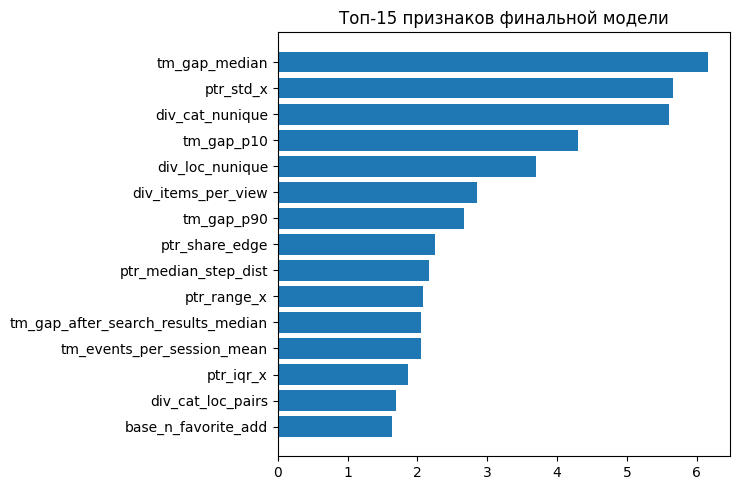

Самые важные признаки:
ptr_share_edge        2.25
tm_gap_p90            2.67
div_items_per_view    2.85
div_loc_nunique       3.70
tm_gap_p10            4.29
div_cat_nunique       5.61
ptr_std_x             5.65
tm_gap_median         6.17
Вклад групп в суммарную важность, %:
tm_      35.2
div_     28.9
ptr_     18.0
cl_       9.3
base_     8.5


In [44]:
importance = pd.concat([pd.Series(m.get_feature_importance(), index=X.columns) for m in final_models],
                       axis=1).mean(axis=1).sort_values()

plt.figure(figsize=(7.5, 5))
plt.barh(importance.tail(15).index, importance.tail(15).to_numpy())
plt.title('Топ-15 признаков финальной модели')
plt.tight_layout()
plt.show()

print('Самые важные признаки:')
print(importance.tail(8).round(2).to_string())

print('Вклад групп в суммарную важность, %:')
print((importance.groupby(importance.index.str.split('_').str[0] + '_').sum()
       / importance.sum() * 100).round(1).sort_values(ascending=False).to_string())